# V5 Safe Calibration + Anchor–Challenger Pair Generator

Цель ноутбука — проверить более продуктовую стратегию A/B-персонализации:

1. первые 2–3 вопроса — безопасная стартовая калибровка;
2. дальше `Semantic active v3` помогает поймать направление;
3. после согласования heuristic state и Preference Model включается anchor–challenger режим;
4. anchor остаётся согласованным с текущей гипотезой вкуса, challenger — информативная, но безопасная альтернатива;
5. дополнительно считаются `audibility`, `acceptability`, `midrange disturbance` и источники вопросов.

Важно: V5 — экспериментальная стратегия. Она проверяет, можно ли сделать вопросы более контролируемыми и продуктово приемлемыми, а не только минимизировать `final_distance`.

## 1. Imports

In [6]:
from personalization.plotting import use_article_style
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from personalization.batch_eval import win_rates_vs_baseline
from personalization.safe_anchor_challenger import (
    V5_DISPLAY_NAMES,
    V5_STRATEGY_NAME,
    run_v5_comparison_on_dataset,
    save_v5_outputs,
    source_usage_table,
    summarize_v5_sessions,
)

use_article_style()


DATASET_PATH = ROOT / 'outputs' / 'datasets' / 'synthetic_users_v21.csv'
FIG_DIR = ROOT / 'outputs' / 'figures'
TABLE_DIR = ROOT / 'outputs' / 'tables'
METRICS_DIR = ROOT / 'outputs' / 'metrics'

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('Dataset:', DATASET_PATH)

ROOT: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization
Dataset: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\datasets\synthetic_users_v21.csv


## 2. Configuration

In [2]:
TARGET_MODE_DISPLAY_NAMES = {
    'random8d': 'Random 8D',
    'semantic4d': 'Semantic 4D',
    'semantic6d': 'Semantic 6D',
    'archetype8d': 'Archetype 8D',
}

TARGET_MODE_ORDER = ['random8d', 'semantic4d', 'semantic6d', 'archetype8d']
STRATEGY_ORDER = ['semantic_active_v21', 'candidate_pool_active', V5_STRATEGY_NAME]

def display_strategy(strategy):
    return V5_DISPLAY_NAMES.get(strategy, strategy)

def add_display_columns(df):
    out = df.copy()
    out['target_mode_display'] = out['target_mode'].map(TARGET_MODE_DISPLAY_NAMES).fillna(out['target_mode'])
    out['strategy_display'] = out['strategy'].map(V5_DISPLAY_NAMES).fillna(out['strategy'])
    return out

## 3. Run experiment

In [3]:
dataset = pd.read_csv(DATASET_PATH)

# По умолчанию берём 50 пользователей на режим, чтобы ноутбук выполнялся быстрее.
# Для полного датасета поставь SAMPLE_PER_MODE = None.
SAMPLE_PER_MODE = 50
if SAMPLE_PER_MODE is not None:
    dataset = (
        dataset
        .groupby('target_mode', group_keys=False)
        .apply(lambda g: g.sample(n=min(SAMPLE_PER_MODE, len(g)), random_state=42))
        .reset_index(drop=True)
    )

print('Dataset rows used:', len(dataset))

sessions, steps, curves = run_v5_comparison_on_dataset(
    dataset,
    baseline_strategies=('semantic_active_v21', 'candidate_pool_active'),
    n_steps=25,
    step_scale=0.6,
    lr=0.25,
    clip_value=2.0,
)

summary = summarize_v5_sessions(sessions)
win_rates = win_rates_vs_baseline(sessions, baseline='semantic_active_v21')
source_usage = source_usage_table(steps)

save_v5_outputs(
    sessions, steps, summary, win_rates, source_usage,
    METRICS_DIR,
    prefix='notebook_v5_safe_anchor_challenger',
)

summary.to_csv(TABLE_DIR / 'notebook_v5_safe_anchor_challenger_summary.csv', index=False)
win_rates.to_csv(TABLE_DIR / 'notebook_v5_safe_anchor_challenger_win_rates.csv', index=False)
source_usage.to_csv(TABLE_DIR / 'notebook_v5_safe_anchor_challenger_source_usage.csv', index=False)

summary

C:\Users\makcc\AppData\Local\Temp\ipykernel_16180\963809680.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(SAMPLE_PER_MODE, len(g)), random_state=42))


Dataset rows used: 200


,target_mode,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,mean_direction_lock_step,mean_ready_step,ready_rate,mean_pair_distance,mean_audibility_score,mean_acceptability_score,mean_midrange_penalty
2,archetype8d,semantic_active_v21,50,1.095608,0.364598,0.097147,0.262498,0.560286,58.324612,NaN,NaN,0.0,NaN,NaN,NaN,NaN
0,archetype8d,candidate_pool_active,50,1.095608,0.477546,0.133387,0.324951,0.622914,43.057348,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,archetype8d,safe_anchor_challenger_v5,50,1.095608,0.595683,0.160116,0.310788,0.634502,26.683049,15.04,14.00,1.0,0.791940,0.860915,0.979673,0.061175
3,random8d,candidate_pool_active,50,2.121827,0.967592,0.445256,0.953201,1.502373,55.593227,NaN,NaN,0.0,NaN,NaN,NaN,NaN
4,random8d,safe_anchor_challenger_v5,50,2.121827,1.419877,0.511347,1.374041,1.664891,32.726517,15.02,14.00,1.0,0.785428,0.855019,0.981601,0.058163
5,random8d,semantic_active_v21,50,2.121827,1.450505,0.484755,1.412383,1.666669,30.716095,NaN,NaN,0.0,NaN,NaN,NaN,NaN
8,semantic4d,semantic_active_v21,50,1.697778,0.431715,0.176675,0.332337,0.851257,70.982809,NaN,NaN,0.0,NaN,NaN,NaN,NaN
6,semantic4d,candidate_pool_active,50,1.697778,0.578102,0.218648,0.506176,0.943762,63.243664,NaN,NaN,0.0,NaN,NaN,NaN,NaN
7,semantic4d,safe_anchor_challenger_v5,50,1.697778,0.634745,0.240906,0.460899,0.905143,57.132504,15.00,14.00,1.0,0.771164,0.846810,0.982551,0.056943
11,semantic6d,semantic_active_v21,50,2.152603,0.520565,0.318778,0.473410,1.165465,75.234983,NaN,NaN,0.0,NaN,NaN,NaN,NaN


## 4. Winners by target mode

In [4]:
winners = (
    summary.sort_values('mean_final_distance')
    .groupby('target_mode')
    .head(1)
    [['target_mode', 'strategy', 'mean_final_distance', 'mean_best_distance', 'mean_improvement_pct']]
    .copy()
)
winners['target_mode'] = winners['target_mode'].map(TARGET_MODE_DISPLAY_NAMES).fillna(winners['target_mode'])
winners['strategy'] = winners['strategy'].map(V5_DISPLAY_NAMES).fillna(winners['strategy'])
winners

,target_mode,strategy,mean_final_distance,mean_best_distance,mean_improvement_pct
2,Archetype 8D,Semantic active v3,0.364598,0.262498,58.324612
8,Semantic 4D,Semantic active v3,0.431715,0.332337,70.982809
11,Semantic 6D,Semantic active v3,0.520565,0.473410,75.234983
3,Random 8D,Candidate pool active,0.967592,0.953201,55.593227


## 5. Mean final distance by target mode

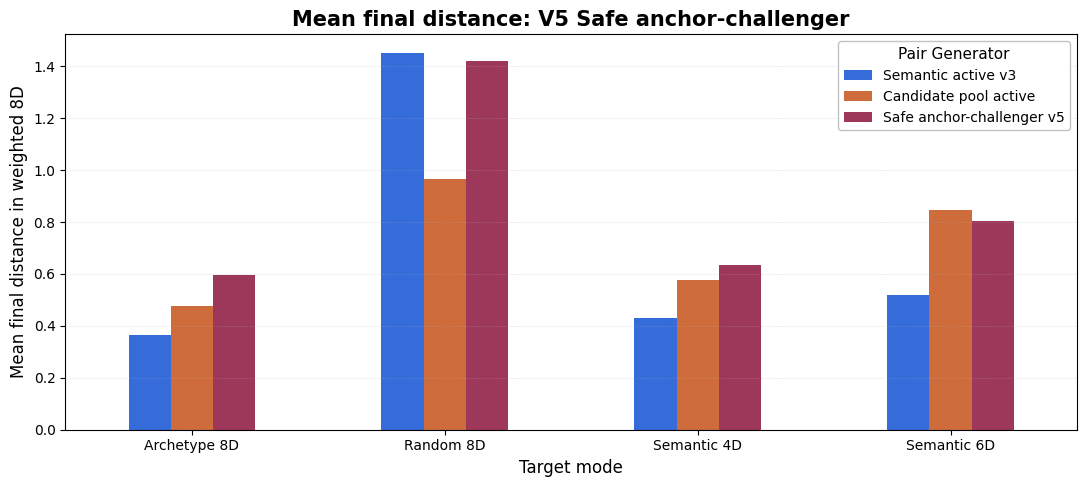

In [7]:
df = add_display_columns(summary)
df['target_mode'] = pd.Categorical(df['target_mode'], TARGET_MODE_ORDER, ordered=True)
df['strategy'] = pd.Categorical(df['strategy'], STRATEGY_ORDER, ordered=True)
df = df.sort_values(['target_mode', 'strategy'])
pivot = df.pivot(index='target_mode_display', columns='strategy_display', values='mean_final_distance')
existing = [V5_DISPLAY_NAMES[s] for s in STRATEGY_ORDER if V5_DISPLAY_NAMES[s] in pivot.columns]
pivot = pivot[existing]

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
pivot.plot(kind='bar', ax=ax)
ax.set_title('Mean final distance: V5 Safe anchor-challenger', fontsize=15, fontweight='bold')
ax.set_xlabel('Target mode')
ax.set_ylabel('Mean final distance in weighted 8D')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(title='Pair Generator', frameon=True, facecolor='white', edgecolor='0.75')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v5_mean_final_distance_by_target.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Convergence on Archetype 8D

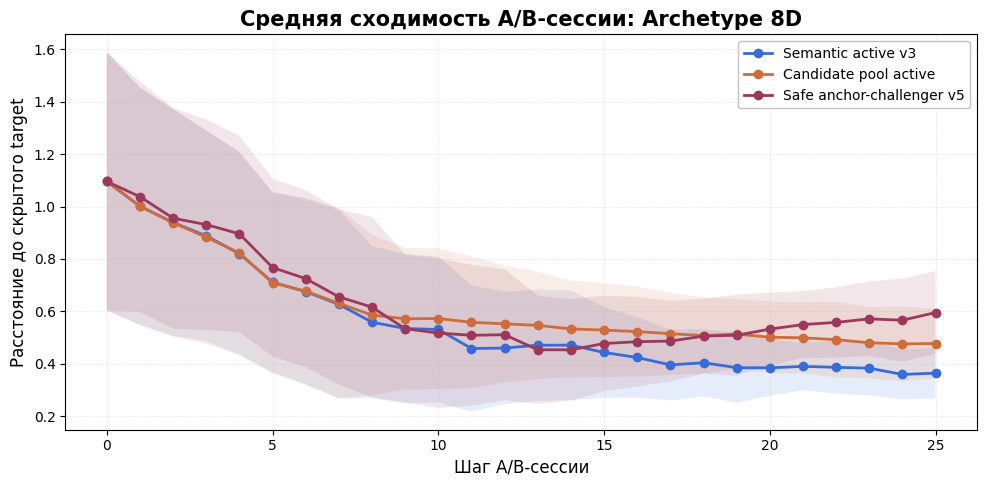

In [8]:
mode = 'archetype8d'
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
for strategy in STRATEGY_ORDER:
    arr = curves.get(mode, {}).get(strategy)
    if arr is None or len(arr) == 0:
        continue
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    x = np.arange(len(mean))
    ax.plot(x, mean, marker='o', linewidth=2, label=display_strategy(strategy))
    ax.fill_between(x, mean - std, mean + std, alpha=0.12)

ax.set_title('Средняя сходимость A/B-сессии: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Шаг A/B-сессии')
ax.set_ylabel('Расстояние до скрытого target')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v5_convergence_archetype8d.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Pair source usage in V5

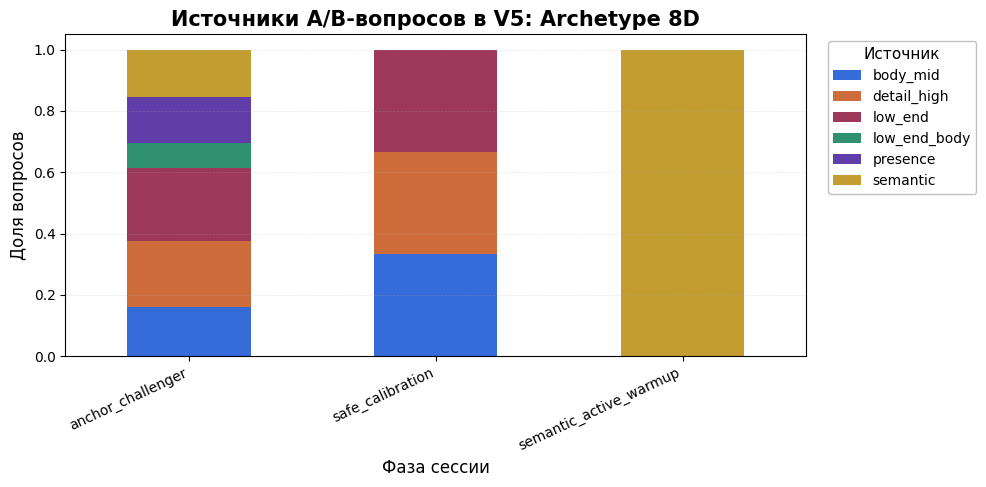

In [9]:
src = source_usage[source_usage['target_mode'] == 'archetype8d'].copy()
if len(src):
    pivot_src = src.pivot_table(index='phase', columns='pair_source_group', values='share', aggfunc='sum').fillna(0.0)
    fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
    pivot_src.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title('Источники A/B-вопросов в V5: Archetype 8D', fontsize=15, fontweight='bold')
    ax.set_xlabel('Фаза сессии')
    ax.set_ylabel('Доля вопросов')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.legend(title='Источник', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'article_v5_pair_source_usage_archetype8d.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('No source usage data')

## 8. Pair quality diagnostics

`acceptability_score` не означает слабый вопрос. Он показывает, что кандидат остаётся безопасным и музыкально правдоподобным. `audibility_score` отвечает за то, чтобы разница между вариантами была достаточно слышимой.

In [10]:
df_steps = steps[steps['target_mode'] == 'archetype8d'].copy()
metrics = ['pair_distance', 'audibility_score', 'acceptability_score', 'midrange_disturbance_penalty']
quality = df_steps.groupby('phase')[metrics].mean().reset_index()
quality

,phase,pair_distance,audibility_score,acceptability_score,midrange_disturbance_penalty
0,anchor_challenger,0.555331,0.844428,0.973494,0.061157
1,safe_calibration,0.711763,0.915237,1.000000,NaN
2,semantic_active_warmup,1.020000,NaN,NaN,NaN


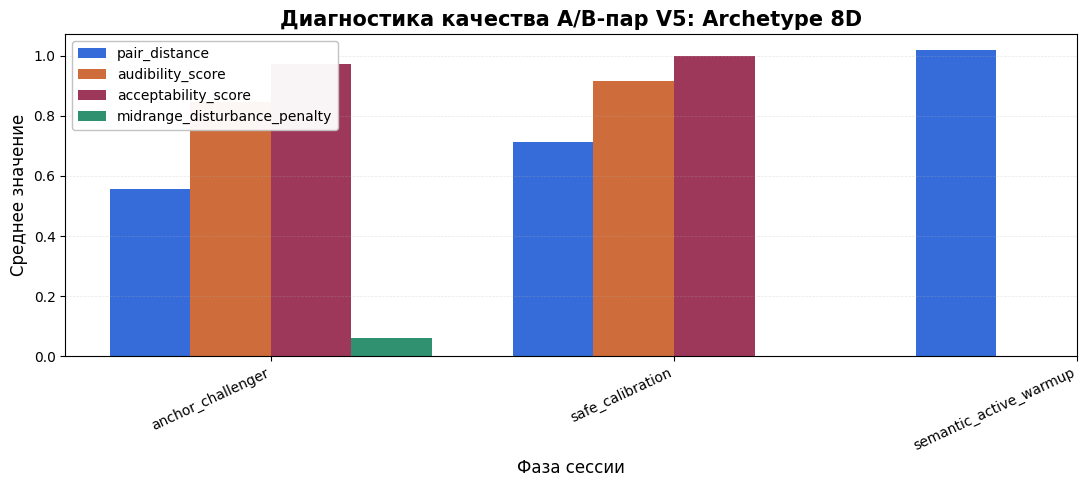

In [11]:
if len(df_steps):
    grouped = quality.copy()
    fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
    x = np.arange(len(grouped))
    width = 0.20
    for i, metric in enumerate(metrics):
        ax.bar(x + (i - 1.5) * width, grouped[metric], width=width, label=metric)
    ax.set_title('Диагностика качества A/B-пар V5: Archetype 8D', fontsize=15, fontweight='bold')
    ax.set_xlabel('Фаза сессии')
    ax.set_ylabel('Среднее значение')
    ax.set_xticks(x)
    ax.set_xticklabels(grouped['phase'], rotation=25, ha='right')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'article_v5_pair_quality_archetype8d.png', dpi=180, bbox_inches='tight')
    plt.show()

## 9. Win-rate vs Semantic active v3

In [12]:
win_rates_display = win_rates.copy()
win_rates_display['target_mode'] = win_rates_display['target_mode'].map(TARGET_MODE_DISPLAY_NAMES).fillna(win_rates_display['target_mode'])
win_rates_display['strategy'] = win_rates_display['strategy'].map(V5_DISPLAY_NAMES).fillna(win_rates_display['strategy'])
win_rates_display

,target_mode,strategy,baseline,win_rate_final_distance,win_rate_best_distance
0,Archetype 8D,Candidate pool active,semantic_active_v21,0.24,0.36
1,Archetype 8D,Safe anchor-challenger v5,semantic_active_v21,0.16,0.22
2,Random 8D,Candidate pool active,semantic_active_v21,0.92,0.92
3,Random 8D,Safe anchor-challenger v5,semantic_active_v21,0.56,0.62
4,Semantic 4D,Candidate pool active,semantic_active_v21,0.12,0.06
5,Semantic 4D,Safe anchor-challenger v5,semantic_active_v21,0.16,0.16
6,Semantic 6D,Candidate pool active,semantic_active_v21,0.06,0.08
7,Semantic 6D,Safe anchor-challenger v5,semantic_active_v21,0.06,0.10


## 10. Interpretation template

```markdown
## Вывод по V5 Safe anchor-challenger

V5 проверяет более продуктовую идею A/B-персонализации: первые вопросы задаются как safe calibration block, затем система использует `Semantic active v3`, а после стабилизации направления переходит к anchor–challenger вопросам. Anchor является согласованным с текущей гипотезой вкуса вариантом, а challenger — безопасной и музыкально осмысленной альтернативой, которая помогает уточнить preference direction.

В отличие от чисто симметричных A/B-пар, V5 дополнительно контролирует `audibility` и `acceptability`: пара должна быть достаточно слышимой, но при этом не должна создавать хаотичные или чрезмерно затрагивающие середину изменения. Это особенно важно для пользовательского сценария, где информативность вопроса не должна достигаться ценой неприятных вариантов.

Результаты V5 следует интерпретировать не только по `final_distance`, но и по диагностическим метрикам качества A/B-пар: `pair_distance`, `audibility_score`, `acceptability_score`, `midrange_disturbance_penalty` и источникам вопросов по фазам сессии. Если V5 не превосходит `Semantic active v3` по final distance, но снижает риск плохих/хаотичных пар и даёт понятный механизм safe challenger, его можно рассматривать как продуктовый слой поверх базового semantic-active поиска.
```